# **Практикум: подготовка к созданию ПО для контент-анализа Telegram**

#  **Шаг 1: выгрузка данных из Telegram-канала**

- выбираем любой Telegram-канал
- находим меню для экспортирования (выгрузки) истории канала
- снимаем все галочки, нам понадобятся только тексты
- настраиваем максимальный размер файла, например, 8 МБ
- выбираем формат `JSON`
- настраиваем папку, куда будут выгружены наши файлы
- дополнительно можно ограничить время публикаций, например, выгрузить данные только за последний месяц

Telegram предлагает нам 2 формата выгрузки данных: `JSON` и `HTML`

**Вопрос:** чем отличаются эти форматы? Где они используются?

**Ответ:**

**JSON (JavaScript Object Notation)** — это формат обмена данными, предназначенный для хранения и передачи структурированных данных между сервером и клиентом. **HTML (HyperText Markup Language)** — язык разметки, используемый для структурирования и отображения содержимого веб-страниц в браузере.

**Основное различие** между ними заключается в том, что JSON ориентирован на хранение и передачу данных, в то время как HTML предназначен для представления этих данных пользователю.

# **Шаг 2: выгрузка файла result.json**

In [3]:
import json

# Загрузка данных
with open("result.json", "r", encoding = "utf-8") as f:
  data = json.load(f)

# Ответ на вопрос: r означает режим чтения для файла

# **Шаг 3: сохраняем все тексты в переменную texts**

In [4]:
type(data)

# json в питоне = дикт

dict

In [5]:
data.keys()

# список ключей для файла

dict_keys(['name', 'type', 'id', 'messages'])

In [6]:
data['messages'][0].keys()

# все ключи

dict_keys(['id', 'type', 'date', 'date_unixtime', 'edited', 'edited_unixtime', 'from', 'from_id', 'photo', 'photo_file_size', 'width', 'height', 'text', 'text_entities', 'reactions'])

**Задание:** выведите на экран несколько примеров текстов из нашего `JSON` и создайте список текстов из нашего документа

```
ПОДСКАЗКА

- создайте список `texts`
- выполните цикл `for` для каждого сообщения по ключу `messages`
- проверьте тип данных элемента по ключу `['text']`: в нашем документе это могут быть строки или списки
  - если текущий элемент по ключу `['text']` представляет собой список, то
    - для каждого элемента данного списка проверьте его тип данных:
      - если это строка, занесите ее в список `texts`
      - иначе: занесите в список `texts` данные, доступные по ключу `text`
  - иначе: занесите в список `texts` данные, доступные по ключу `text`
```

In [7]:
import json

# Загрузка данных
with open("result.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Создаем список для хранения текстов
texts = []

# Проходим по всем сообщениям в 'messages'
for message in data['messages']:
    # Проверяем, является ли 'text' строкой или списком
    if isinstance(message['text'], list):
        # Если это список, проходим по каждому элементу
        for item in message['text']:
            if isinstance(item, str):  # Если элемент списка - строка, добавляем в texts
                texts.append(item)
            else:  # Если элемент не строка, добавляем текст из ключа 'text'
                texts.append(item.get('text', ''))
    else:  # Если 'text' не список, добавляем строку напрямую
        texts.append(message['text'])

# Выводим несколько примеров текстов из списка
for i in range(min(5, len(texts))):  # Печатаем первые 5 текстов
    print(f"Пример {i+1}: {texts[i]}")

Пример 1: Сегодня особенно хочется верховных уютов и красивых вещей. Поэтому собрала на фристайле подборку на Lamoda из разного. Что нашла по приятным ценам:


Пример 2: черное постельное белье
Пример 3:  — 5232₽

Пример 4: набор тарелок
Пример 5:  — 4266₽



**Задание:** импортируйте модуль `random` и выведите первые 100 символов для 10 случайных текстов

```
ПОДСКАЗКА

- с помощью метода `random.sample` создайте список `sample_texts` из 10 случайных текстов из списка `texts`
- с помощью цикла `for` для каждого текста выведите первые 100 символов каждого элемента
```

In [8]:
import random

sample_texts = random.sample(texts, 10)

for text in sample_texts:
  if text.strip():
    print(f'Первые 100 символов: {text[:100]}')
  else:
    print('Пустой текст')

Первые 100 символов:  — 2260₽

Первые 100 символов: подсвечники
Первые 100 символов: "Москва-80".
Первые 100 символов:  — 5232₽

Пустой текст
Пустой текст
Первые 100 символов: . Мне попалась чудесная врач, с которой я теперь хочу дружить. Помимо базы она подсветила мне кое-чт
Пустой текст
Пустой текст
Первые 100 символов: "Газированная вода"


Согласно результатам, некоторые элементы ничего не содержат, и получается пустой текст. Исходя из этого, нам нужна предобработка текста, чтобы исключить такие случаи.

# Шаг 4: чистка текста с помощью регулярных выражений

In [9]:
import re

**Задание:**  выберите паттерн для очистки ваших данных и произведите чистку

In [10]:
cleaned_texts = []

patterns = [
    r'https?://\S+',  # удаление ссылок
    r'[@#]\w+',       # удаление хештегов и упоминаний
    r'[\.,:;\'"!?]',  # удаление знаков препинания
    r'[A-z]+',        # удаление слов написанных латиницей
    r'\n+'
]

for text in texts:
  cleaned_text = text.strip() # удаление переносов строки (\n)
  for pattern in patterns:
    cleaned_text = re.sub(pattern, '', cleaned_text)
  if text != '':
    cleaned_texts.append(cleaned_text)

print(cleaned_texts)

['Сегодня особенно хочется верховных уютов и красивых вещей Поэтому собрала на фристайле подборку на  из разного Что нашла по приятным ценам', 'черное постельное белье', '— 5232₽', 'набор тарелок', '— 4266₽', 'ваза', '— 2232₽', 'подсвечники', '— 2366₽', 'кружка', '— 490₽', 'свеча', '— 2976₽', 'подсвечник', '— 1606₽', 'тарелка', '— 2260₽', 'набор бокалов', '— 2792₽', 'Высший аркан выходного дня выглядит так Провела весь день на максимально расслабленном в своей новой пижаме от - Я в восторге от каждой детали начиная от элегантной упаковки заканчивая кроем Про принт вообще молчу (он 10/10) И каждый раз проходя мимо зеркала карты таро меня безумно веселят', 'Смотрим на новинки моего любимого бренда ’ Обожаю их за то что каждый предмет мемнее другого Чего стоит например', 'кольцо', 'в виде коробки с кольцом Или', 'серьги-ногти', 'Сразу говорю что такое нужно уметь носить и если вы серьезно относитесь к себе то вам не понравится Для понимания и наглядности принесла Анастасию Миронову в их с

# Шаг 5: удаление стоп-слов 

**Задание:** удалите стоп-слова с помощью списка стоп-слов из `spacy`

In [11]:
!pip install nltk

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words("russian"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Veronika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


  Using cached https://github.com/explosion/spacy-models/releases/download/ru_core_news_sm-3.8.0/ru_core_news_sm-3.8.0-py3-none-any.whl (15.3 MB)
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
['сегодня', 'особенно', 'хотеться', 'верховный', 'уют', 'красивый', 'вещь', 'поэтому', 'собрать', 'фристайле', 'подборка', 'разный', 'найти', 'приятный', 'цена', 'чёрный', 'постельный', 'бельё', '5232', '₽', 'набор', 'тарелка', '4266', '₽', 'ваза', '2232', '₽', 'подсвечник', '2366', '₽', 'кружка', '490', '₽', 'свеча', '2976', '₽', 'подсвечник', '1606', '₽', 'тарелка', '2260', '₽', 'набор', 'бокал', '2792', '₽', 'высокий', 'аркан', 'выходной', 'день', 'выглядеть', 'провести', 'весь', 'день', 'максимально', 'расслабить', 'свой', 'новый', 'пижама', 'восторг', 'каждый', 'деталь', 'начинать', 'элегантный', 'упаковка', 'заканчивать', 'крой', 'принт', 'вообще', 'молчу', '10/10', 'каждый', 'проходить', 'мимо', 'зеркало', 'карта', 'таро', 'безумно', '

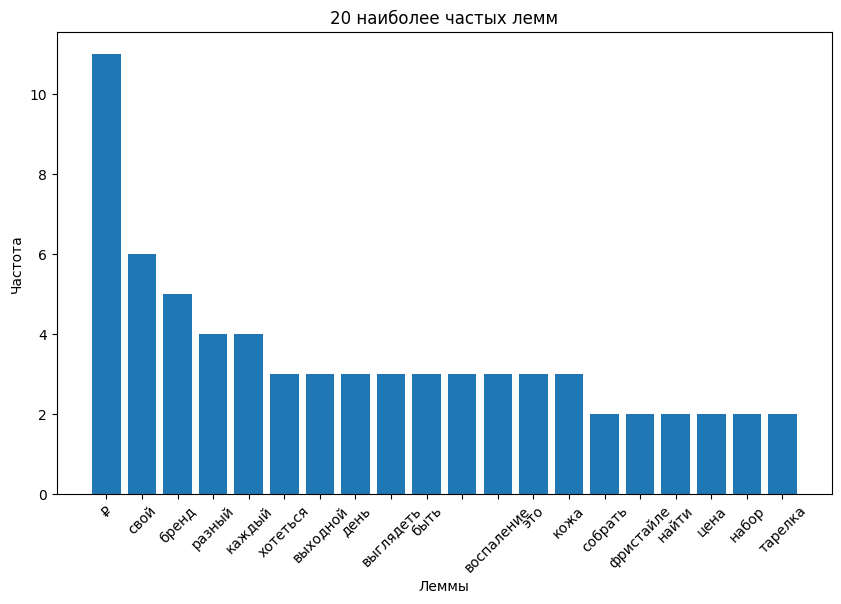

In [12]:
!pip install spacy
!python -m spacy download ru_core_news_sm


import spacy

# Загружаем модель spaCy для русского языка
nlp = spacy.load("ru_core_news_sm")

cleaned_words = []

for text in cleaned_texts:
    # Применяем модель spaCy для токенизации и лемматизации
    doc = nlp(text)

    # Токенизация и лемматизация: приводим все слова в нижний регистр и исключаем стоп-слова
    cleaned = [token.lemma_.lower() for token in doc if token.text.lower() not in stop_words and not token.is_punct and token.lemma_ != ' ']

    cleaned_words.extend(cleaned)

# Выводим результат
print(cleaned_words)

from collections import Counter

# Создаем частотный словарь лемм с помощью Counter
lemma_counts = Counter(cleaned_words)

# Выводим частотный словарь
print(lemma_counts)

# Получаем 20 наиболее частых лемм
most_common_lemmas = lemma_counts.most_common(20)

# Разбиваем на две части для отображения на графике
lemmas, counts = zip(*most_common_lemmas)

!pip install matplotlib

import matplotlib.pyplot as plt

# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.bar(lemmas, counts)
plt.xticks(rotation=45)
plt.title("20 наиболее частых лемм")
plt.xlabel("Леммы")
plt.ylabel("Частота")
plt.show()

# Шаг 6: анализ текста

**Задание:** произвести разметку именованных сущностей с помощью `spacy`

In [13]:
!python3 -m spacy download ru_core_news_sm -q

Python 


In [14]:
import spacy

# Загружаем модель для русского языка
nlp = spacy.load("ru_core_news_sm")

entities = []
for text in cleaned_texts:
    doc = nlp(text)
    # Добавляем метку сущности в список
    entities.extend([ent.label_ for ent in doc.ents])

Визуализация результата:

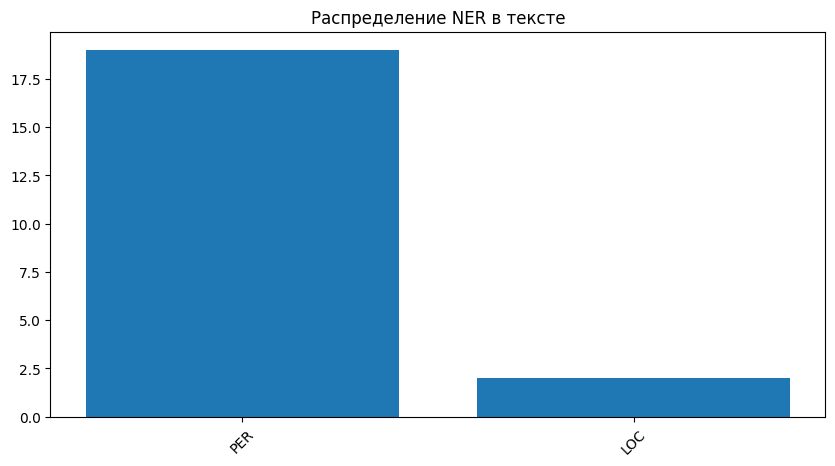

In [15]:
from collections import Counter
import matplotlib.pyplot as plt

# Гистограмма NER
entity_counts = Counter(entities) # Посчитаем количество вхождений именованных сущностей
plt.figure(figsize=(10, 5))
plt.bar(entity_counts.keys(), entity_counts.values())
plt.xticks(rotation=45)
plt.title("Распределение NER в тексте")
plt.show()

In [16]:
# PoS-анализ
pos_counts = Counter()
for text in cleaned_texts:
    doc = nlp(text)
    pos_counts.update([token.pos_ for token in doc])

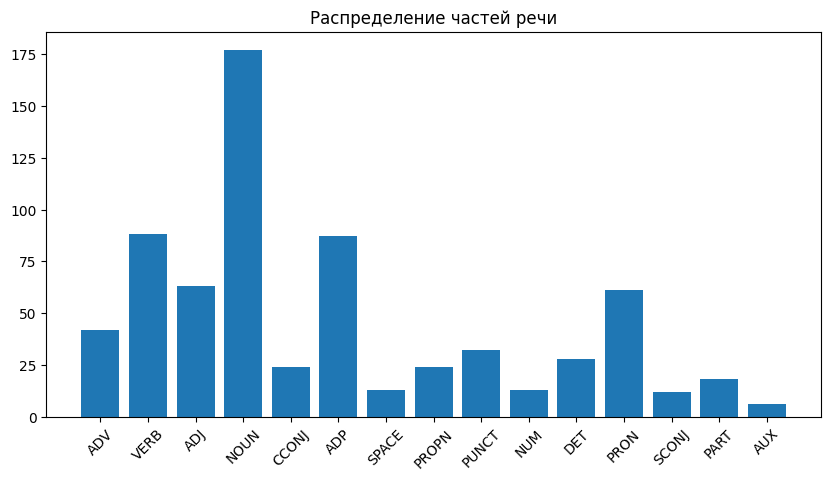

In [17]:
# Гистограмма PoS
plt.figure(figsize=(10, 5))
plt.bar(pos_counts.keys(), pos_counts.values())
plt.xticks(rotation=45)
plt.title("Распределение частей речи")
plt.show()